<a href="https://colab.research.google.com/github/Souvik-31/Medical-Anomaly/blob/main/skip-ts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
torch.cuda.is_available(), torch.cuda.get_device_name(0)

(True, 'Tesla T4')

In [ ]:
!unzip Skip-TS.zip


Archive:  Skip-TS.zip
   creating: skip-ts1/
  inflating: skip-ts1/dataset.py     
   creating: skip-ts1/datasets/
  inflating: skip-ts1/datasets/.DS_Store  
   creating: skip-ts1/datasets/head_ct/
  inflating: skip-ts1/datasets/head_ct/.DS_Store  
   creating: skip-ts1/datasets/head_ct/ground_truth/
  inflating: skip-ts1/datasets/head_ct/ground_truth/.DS_Store  
   creating: skip-ts1/datasets/head_ct/ground_truth/bad/
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/000_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/001_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/002_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/003_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/004_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/005_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/006_mask.png  
  inflating: skip-ts1/datasets/head_ct/ground_truth/bad/007_mask.png  
  inflati

In [ ]:
!pip install torch torchvision torchaudio tqdm numpy pillow


In [ ]:
%cd /content/skip-ts1


/content/skip-ts1


In [ ]:
!python main.py


cuda
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/wide_resnet50_racm-8234f177.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_racm-8234f177.pth
100% 263M/263M [00:04<00:00, 62.5MB/s]
100% 4/4 [00:04<00:00,  1.24s/it]
100% 4/4 [00:03<00:00,  1.25it/s]
100% 4/4 [00:03<00:00,  1.20it/s]
100% 4/4 [00:03<00:00,  1.15it/s]
100% 4/4 [00:03<00:00,  1.22it/s]
100% 4/4 [00:03<00:00,  1.23it/s]
100% 4/4 [00:03<00:00,  1.19it/s]
100% 4/4 [00:03<00:00,  1.15it/s]
100% 4/4 [00:03<00:00,  1.21it/

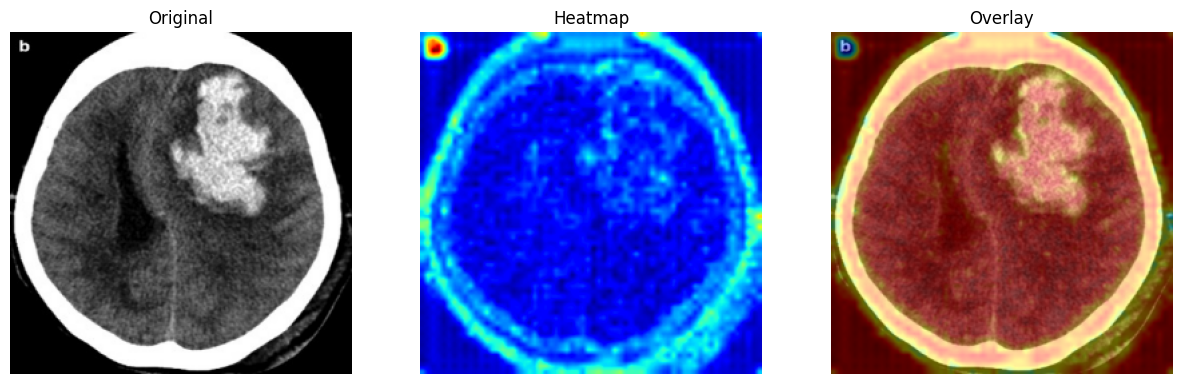

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from encoder import wide_resnet50_2
from decoder import de_wide_resnet50_2
from eval_func import evaluation  # for anomaly score functions
from dataset import get_data_transforms
import os

# -----------------------------------------
# 1. Load trained model
# -----------------------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'

encoder = wide_resnet50_2(pretrained=True).to(device)
encoder.eval()

decoder = de_wide_resnet50_2(pretrained=False).to(device)

# <<< CHANGE THIS: load your best checkpoint >>>
checkpoint = "/content/skip-ts1/checkpoints/wide_res5090250auc=0.875.pth"
decoder.load_state_dict(torch.load(checkpoint, map_location=device))
decoder.eval()

# -----------------------------------------
# 2. Choose a test image
# -----------------------------------------
test_img_path = "/content/skip-ts1/datasets/head_ct/test/bad/000.png"

img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------------------
# 3. Apply same transform as training
# -----------------------------------------
image_size = 256
data_transform, _ = get_data_transforms(image_size, image_size)

pil = transforms.ToPILImage()(img_rgb)
input_tensor = data_transform(pil).unsqueeze(0).to(device)

# -----------------------------------------
# 4. Forward pass through encoder & decoder
# -----------------------------------------
with torch.no_grad():
    features = encoder(input_tensor)
    outputs = decoder(features[3], features[0:3], res=3)

# -----------------------------------------
# 5. Compute anomaly heatmap
# (difference between encoder and decoder)
# -----------------------------------------
feature_orig = features[0].squeeze().cpu().numpy()
feature_rec  = outputs[0].squeeze().cpu().numpy()

# Use L2 difference for heatmap
heatmap = np.sqrt(((feature_orig - feature_rec)**2).sum(axis=0))

# Normalize
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))

# Colorize
heatmap_color = cv2.applyColorMap((heatmap*255).astype(np.uint8), cv2.COLORMAP_JET)
overlay = (0.4 * heatmap_color + 0.6 * img_rgb).astype(np.uint8)

# -----------------------------------------
# 6. Plot results
# -----------------------------------------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()
